In [1]:
RANDOM_SEED = 336461617

In [2]:
from typing import Optional, Self
from dataclasses import dataclass
import numpy as np
import numpy.typing as npt
from collections import deque

@dataclass
class Node:
    def __init__(self):
        self.is_leaf: bool = False
        self.prediction: Optional[int] = None
        self.feature: Optional[int] = None
        self.children: dict[int, Self] = {}

class DecisionTree:
    def __init__(self, max_depth: int, num_features: int):
        self.max_depth = max_depth
        self.num_features = num_features
        self.root: Optional[Node] = None

    def fit(self, features: npt.NDArray[np.int_], labels: npt.NDArray[np.int_]) -> Self:
        self.root = Node()
        Q: deque[tuple[Node, npt.NDArray[np.int_], npt.NDArray[np.int_], int]] = deque()
        Q.append((self.root, features, labels, 0))

        while Q:
            node, elem_features, elem_labels, depth = Q.popleft()

            if self._is_pure(elem_labels) or depth >= self.max_depth:
                node.is_leaf = True
                node.prediction = self._majority(elem_labels)
                continue

            feature_subset = self._random_features(elem_features.shape[1])
            best_feature = self._best_feature(elem_features, elem_labels, feature_subset)
            node.feature = best_feature
            feature_options = np.unique(elem_features[:, best_feature])

            for feature in feature_options:
                mask = elem_features[:, best_feature] == feature
                features_child, labels_child = elem_features[mask], elem_labels[mask]

                if labels_child.size == 0:
                    continue

                child = Node()
                node.children[feature] = child
                Q.append((child, features_child, labels_child, depth + 1))

        return self

    def predict(self, data_points: npt.NDArray[np.int_]) -> npt.NDArray[np.int_]:
        return np.array([self._predict_one(dp) for dp in data_points])

    def _random_features(self, n_features: int) -> npt.NDArray[np.int_]:
        return np.random.choice(n_features, self.num_features, replace=False)

    def _majority(self, labels: npt.NDArray[np.int_]) -> int:
        return int(np.bincount(labels).argmax())

    def _is_pure(self, labels: npt.NDArray[np.int_]) -> bool:
        return np.unique(labels).size == 1

    def _entropy(self, labels: npt.NDArray[np.int_]) -> float:
        counts = np.bincount(labels)
        probabilities = counts[counts > 0] / labels.size
        return float(-np.sum(probabilities * np.log2(probabilities)))

    def _best_feature(self, features: npt.NDArray[np.int_], labels: npt.NDArray[np.int_], feature_subset: npt.NDArray[np.int_]) -> int:
        information_gains = [self._information_gain(features, labels, feature) for feature in feature_subset]
        best_index = int(np.argmax(information_gains))
        return int(feature_subset[best_index])

    def _information_gain(self, features: npt.NDArray[np.int_], labels: npt.NDArray[np.int_], feature_index: int) -> float:
        parent_entropy = self._entropy(labels)
        feature_values = np.unique(features[:, feature_index])
        weighted_entropy = 0.0

        for value in feature_values:
            mask = features[:, feature_index] == value
            labels_subset = labels[mask]

            if labels_subset.size == 0:
                continue

            weight = labels_subset.size / labels.size
            weighted_entropy += weight * self._entropy(labels_subset)

        return parent_entropy - weighted_entropy

    def _predict_one(self, data_point: npt.NDArray[np.int_]) -> int:
        node = self.root

        while node is not None and not node.is_leaf:
            feature_value = int(data_point[node.feature])

            if feature_value not in node.children:
                return node.prediction if node.prediction is not None else 0

            node = node.children[feature_value]

        assert node is not None
        return node.prediction if node.prediction is not None else 0


In [3]:
from typing import cast
from tqdm.autonotebook import tqdm

class RandomForest:
    def __init__(self, n_trees: int, max_depth: int, num_features: int):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.num_features = num_features
        self.trees: list[DecisionTree] = []

    def fit(self, features: npt.NDArray[np.int_], labels: npt.NDArray[np.int_], use_tqdm: bool = True) -> Self:
        self.trees = []
        n_samples = features.shape[0]

        for _ in (tqdm(range(self.n_trees), desc="Creating the RandomForest") if use_tqdm else range(self.n_trees)):
            indices: npt.NDArray[np.int_] = cast(npt.NDArray[np.int_], np.random.choice(
                n_samples,
                size=n_samples,
                replace=True
            ))

            bootstrap_features = features[indices]
            bootstrap_labels = labels[indices]

            tree = DecisionTree(
                max_depth=self.max_depth,
                num_features=self.num_features
            )

            self.trees.append(tree.fit(bootstrap_features, bootstrap_labels))

        return self

    def predict(self, features: npt.NDArray[np.int_], use_tqdm: bool = True) -> npt.NDArray[np.int_]:
        tree_predictions = np.array(
            [tree.predict(features) for tree in (tqdm(self.trees, desc="Running the RandomForest predictions") if use_tqdm else self.trees)]
        )

        tree_predictions = np.asarray(tree_predictions)

        return np.array([
            self._majority_vote(tree_predictions[:, i])
            for i in range(tree_predictions.shape[1])
        ])

    def _majority_vote(self, predictions: npt.NDArray[np.int_]) -> int:
        return int(np.bincount(predictions).argmax())


C:\Users\pitkw\AppData\Local\Temp\ipykernel_14172\3763001223.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [4]:
import kagglehub
from pathlib import Path

path = Path(kagglehub.dataset_download("bhadaneeraj/cardio-vascular-disease-detection"))
print(path)

C:\Users\pitkw\.cache\kagglehub\datasets\bhadaneeraj\cardio-vascular-disease-detection\versions\1


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split


def load_dataset(dir_path: Path, file_path: Path | str, seperator: str = ";"):
    return pd.read_csv(dir_path / file_path, sep=seperator)


def preprocess_cardio_dataset(df: pd.DataFrame) -> tuple[npt.NDArray[np.int_], npt.NDArray[np.int_]]:
    df = df.drop(columns=["id"], errors="ignore")

    labels = df["cardio"].to_numpy(dtype=np.int_)
    features = df.drop(columns=["cardio"]).to_numpy(dtype=np.float64)

    age = features[:, 0]
    age_bins = np.array([20, 30, 45, 60]) * 365
    features[:, 0] = np.digitize(age, age_bins)

    height = features[:, 2]
    height_bins = [160, 170, 180, 190]
    features[:, 0] = np.digitize(height, height_bins)

    weight = features[:, 3]
    weight_bins = [60, 75, 90, 110]
    features[:, 3] = np.digitize(weight, weight_bins)

    ap_hi = features[:, 4]
    ap_hi_bins = [120, 140, 160, 180]
    features[:, 4] = np.digitize(ap_hi, ap_hi_bins)

    ap_lo = features[:, 5]
    ap_lo_bins = [80, 90, 100, 110]
    features[:, 5] = np.digitize(ap_lo, ap_lo_bins)

    features = features.astype(np.int_)
    return features, labels


def split_dataset(features: npt.NDArray[np.int_], labels: npt.NDArray[np.int_], test_size: float = 0.3)-> tuple[npt.NDArray[np.int_], npt.NDArray[np.int_], npt.NDArray[np.int_], npt.NDArray[np.int_], npt.NDArray[np.int_],npt.NDArray[np.int_]]:
    features_train, features_temp, labels_train, labels_temp = cast(
        tuple[npt.NDArray[np.int_], npt.NDArray[np.int_], npt.NDArray[np.int_], npt.NDArray[np.int_]],
        train_test_split(
            features,
            labels,
            test_size=test_size,
            random_state=RANDOM_SEED,
            stratify=labels
        )
    )

    features_val, features_test, labels_val, labels_test = cast(
        tuple[npt.NDArray[np.int_], npt.NDArray[np.int_], npt.NDArray[np.int_], npt.NDArray[np.int_]],
        train_test_split(
            features_temp,
            labels_temp,
            test_size=0.5,
            random_state=RANDOM_SEED,
            stratify=labels_temp
        )
    )

    return (
        features_train,
        features_val,
        features_test,
        labels_train,
        labels_val,
        labels_test
    )


def prepare_cardio_data(dir_path: Path, file_path: Path | str, test_size: float = 0.3):
    df = load_dataset(dir_path, file_path)
    features, labels = preprocess_cardio_dataset(df)
    return split_dataset(features, labels, test_size)



In [6]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

@dataclass
class TestResult:
    accuracy: float
    f1: float
    confusion_matrix: npt.NDArray[np.float64]

    def __str__(self) -> str:
        return self.to_string()

    def to_string(self, comparison: bool = False) -> str:
        string = f"Accuracy: {self.accuracy}{" %" if comparison else ""}" + \
                 f"\nF1: {self.f1}{" %" if comparison else ""}" + \
                 (f"\nConfusion Matrix: \n{self.confusion_matrix}" if not comparison else "")
        return string

    def compare_to(self, other: Self):
        return TestResult(
            self.accuracy / other.accuracy * 100,
            self.f1 / other.f1 * 100,
            np.array([])
        )

def perform_test(n_trees: int, max_depth: int, num_features: int, use_test: bool = False, test_size: float = 0.3, compare_to_builtin: bool = False, use_tqdm: bool = True) -> TestResult:
    features_train, features_val, features_test, labels_train, labels_val, labels_test = prepare_cardio_data(path, "cardio_train.csv", test_size)
    rf = RandomForest(
        n_trees=n_trees,
        max_depth=max_depth,
        num_features=num_features
    ) if not compare_to_builtin else RandomForestClassifier(
        n_estimators=n_trees,
        max_depth=max_depth,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

    features = features_val if not use_test else features_test
    labels = labels_val if not use_test else labels_test

    if compare_to_builtin:
        rf.fit(features_train, labels_train)
        labels_pred = rf.predict(features)
    else:
        rf.fit(features_train, labels_train, use_tqdm)
        labels_pred = rf.predict(features, use_tqdm)
    return TestResult(
        float(accuracy_score(labels, labels_pred)),
        float(f1_score(labels, labels_pred)),
        confusion_matrix(labels, labels_pred)
    )


def test(n_trees: int, max_depth: int, num_features: int, use_test: bool = False, test_size: float = 0.3, compare_to_builtin: bool = True) -> None:
    test_result = perform_test(n_trees, max_depth, num_features, use_test, test_size)
    print("Result:")
    print(test_result)
    print()

    if compare_to_builtin:
        builtin_test_result = perform_test(n_trees, max_depth, num_features, use_test, test_size, True)
        print("Builtin result: ")
        print(builtin_test_result)
        print()

        comparison_result = test_result.compare_to(builtin_test_result)
        print("Comparison:")
        print(comparison_result.to_string(True))



In [7]:
test(
    n_trees=10,
    max_depth=5,
    num_features=4
)

Creating the RandomForest:   0%|          | 0/10 [00:00<?, ?it/s]

Running the RandomForest predictions:   0%|          | 0/10 [00:00<?, ?it/s]

Result:
Accuracy: 0.7094757094757095
F1: 0.664071190211346
Confusion Matrix: 
[[4390  812]
 [2208 2985]]

Builtin result: 
Accuracy: 0.718999518999519
F1: 0.6802408319649699
Confusion Matrix: 
[[4367  835]
 [2086 3107]]

Comparison:
Accuracy: 98.67540808134868 %
F1: 97.62295337271718 %


In [33]:
from typing import Iterable, Sequence
import matplotlib.pyplot as plt


def grid_test(
    n_trees_range: Iterable[int],
    max_depth_range: Iterable[int],
    num_features: int,
    use_test: bool = False,
    test_size: float = 0.3,
    compare_to_builtin: bool = False
) -> list[tuple[int, int, float, float]]:

    results: list[tuple[int, int, float, float]] = []

    outer = tqdm(n_trees_range, desc="n_trees analysis", position=0)

    for n_trees in outer:
        inner = tqdm(max_depth_range, desc=f"max_depth (trees={n_trees})",
                     position=1, leave=False)

        for max_depth in inner:
            res = perform_test(
                n_trees,
                max_depth,
                num_features,
                use_test,
                test_size,
                compare_to_builtin,
                False
            )

            results.append((n_trees, max_depth, res.accuracy, res.f1))

    return results


def unpack_results(results: list[tuple[int, int, float, float]]):
    n_trees = np.array([r[0] for r in results])
    max_depth = np.array([r[1] for r in results])
    accuracy = np.array([r[2] for r in results])
    f1 = np.array([r[3] for r in results])

    return n_trees, max_depth, accuracy, f1


def plot_surfaces(results):

    n_trees, max_depth, accuracy, f1 = unpack_results(results)

    trees_unique = np.unique(n_trees)
    depth_unique = np.unique(max_depth)

    X, Y = np.meshgrid(trees_unique, depth_unique, indexing="ij")

    Z_acc = accuracy.reshape(len(trees_unique), len(depth_unique))
    Z_f1 = f1.reshape(len(trees_unique), len(depth_unique))

    fig = plt.figure(figsize=(14, 6))

    ax1 = fig.add_subplot(121, projection='3d')
    surf1 = ax1.plot_surface(X, Y, Z_acc, cmap='viridis')

    ax1.set_title("Accuracy")
    ax1.set_xlabel("Number of Trees")
    ax1.set_ylabel("Max Depth")
    ax1.set_zlabel("Accuracy")

    fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)

    ax2 = fig.add_subplot(122, projection='3d')
    surf2 = ax2.plot_surface(X, Y, Z_f1, cmap='plasma')

    ax2.set_title("F1 Score")
    ax2.set_xlabel("Number of Trees")
    ax2.set_ylabel("Max Depth")
    ax2.set_zlabel("F1")

    fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

    plt.tight_layout()
    plt.show()


def get_best_result(
    results: Sequence[tuple[int, int, float, float]]
) -> tuple[int, int, float, float]:
    return max(results, key=lambda r: r[2])

n_trees analysis:   0%|          | 0/10 [00:00<?, ?it/s]

max_depth (trees=10):   0%|          | 0/9 [00:00<?, ?it/s]

max_depth (trees=20):   0%|          | 0/9 [00:00<?, ?it/s]

max_depth (trees=30):   0%|          | 0/9 [00:00<?, ?it/s]

max_depth (trees=40):   0%|          | 0/9 [00:00<?, ?it/s]

...

max_depth (trees=60):   0%|          | 0/9 [00:00<?, ?it/s]

max_depth (trees=70):   0%|          | 0/9 [00:00<?, ?it/s]

max_depth (trees=80):   0%|          | 0/9 [00:00<?, ?it/s]

max_depth (trees=90):   0%|          | 0/9 [00:00<?, ?it/s]

max_depth (trees=100):   0%|          | 0/9 [00:00<?, ?it/s]

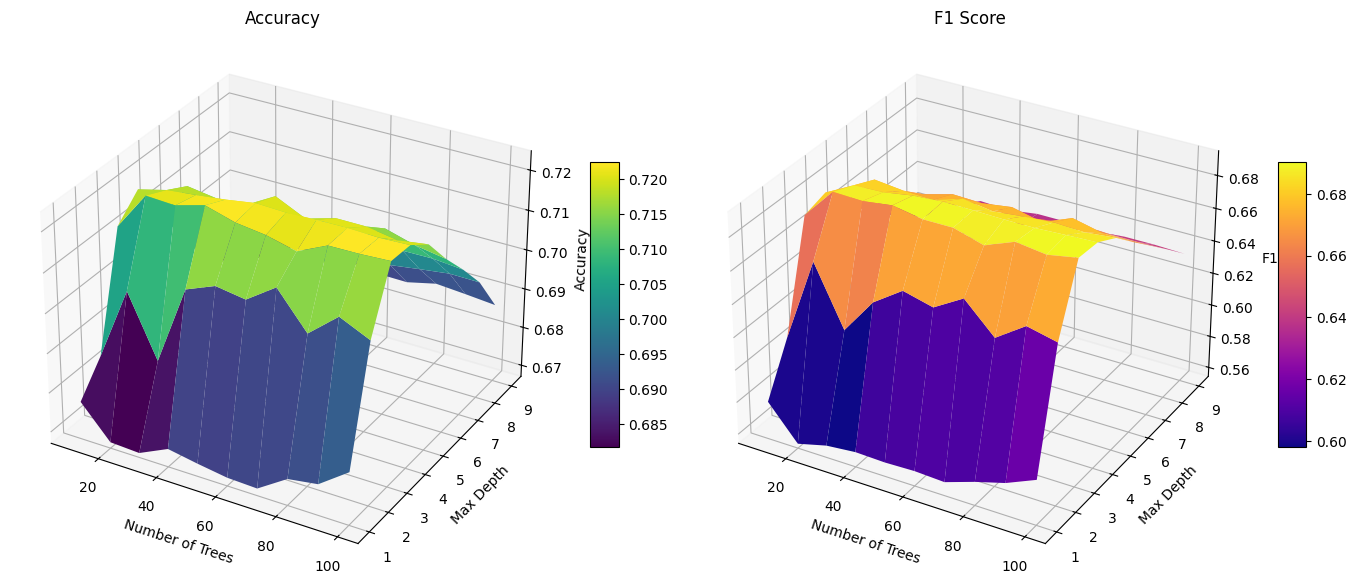

(40, 3, 0.7236171236171236, 0.692035587951549)


In [35]:
results = grid_test(
    n_trees_range=range(10, 101, 10),
    max_depth_range=range(1, 10, 1),
    num_features=4
)

plot_surfaces(results)
best = get_best_result(results)
print(best)